<a href="https://colab.research.google.com/github/divyadharshiniug/24ADI006_24BAD023/blob/EX-2/DL_EXP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPT NO: 2 — Comparative Study of Activation Functions and Optimization Algorithms in Deep Learning

**Name:** DIVYADHARSHINI U G
**Roll No:** 24BAD023



In [ ]:
# ==========================================================
# COMMON SETUP CELL - run this first
# ==========================================================
# Roll No: 24BAD023

import numpy as np                       # numerical operations
import matplotlib.pyplot as plt          # plotting activation functions and training curves
import tensorflow as tf                  # deep learning framework
from tensorflow import keras
from tensorflow.keras import layers
import time                              # to measure training/convergence time
import pandas as pd                      # to build comparison tables

# Fix random seeds for reproducibility of results across runs
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


---
## Task A: Visualization of Activation Functions

**Roll No:** 24BAD023

We implement Sigmoid, Tanh and ReLU from their mathematical definitions (not just calling a
library function) so that the formula and shape of each function is clear, then plot them
together with their derivatives (gradients) to study saturation behaviour.


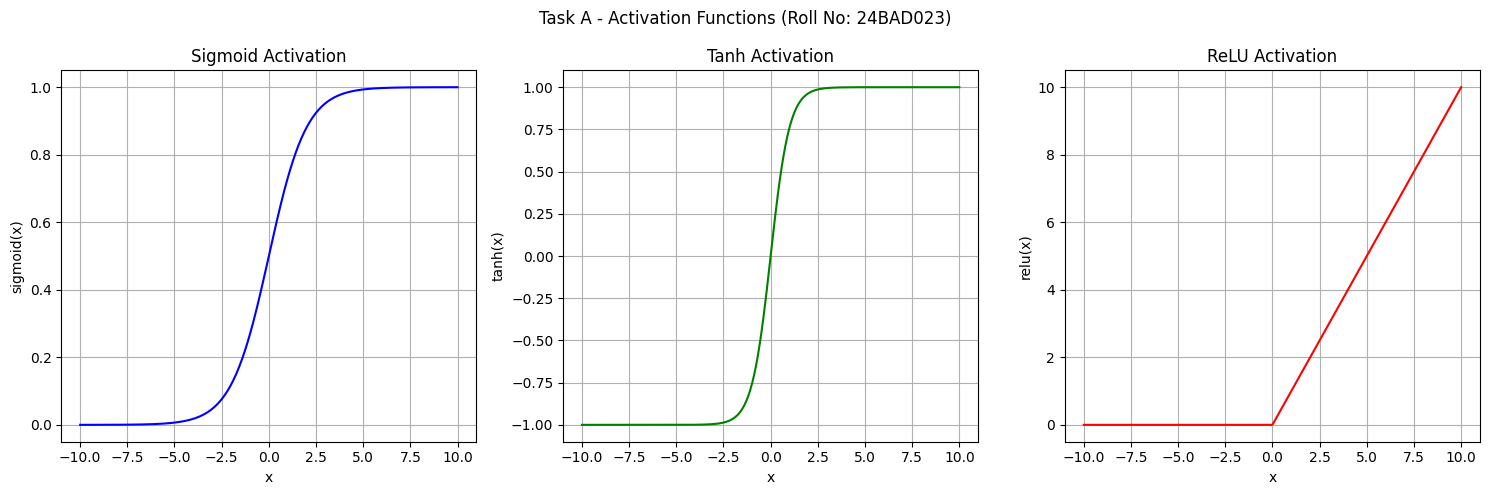

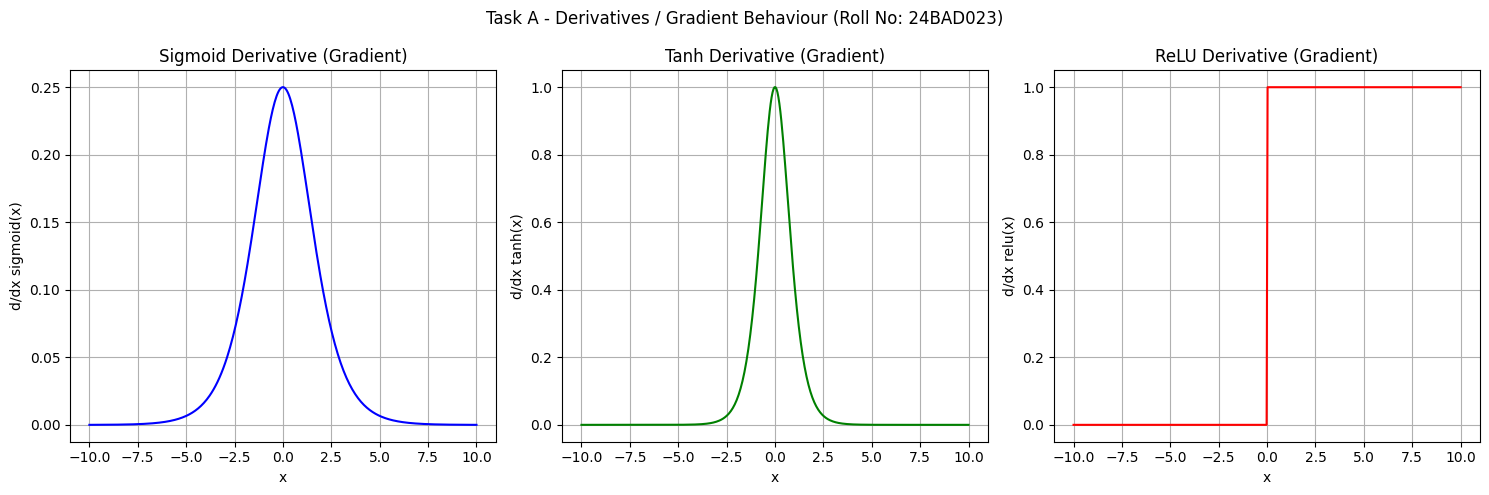

Activation Output Range Zero-Centred    Saturates  Computation Cost       Vanishing Gradient                           Typical Use
   Sigmoid       (0, 1)           No    Both ends        High (exp)                   Severe  Output layer (binary classification)
      Tanh      (-1, 1)          Yes    Both ends        High (exp)                 Moderate            Hidden layers (older RNNs)
      ReLU     [0, inf)           No Only for x<0 Very Low (max op) Mild (dead ReLU for x<0) Hidden layers (most modern DNNs/CNNs)


In [ ]:
# ==========================================================
# TASK A: Visualization of Activation Functions
# Roll No: 24BAD023
# ==========================================================

# ---- 1. Define activation functions manually ----

def sigmoid(x):
    """Sigmoid squashes input to the range (0, 1)."""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    """Tanh squashes input to the range (-1, 1). Zero-centred, unlike sigmoid."""
    return np.tanh(x)

def tanh_derivative(x):
    t = tanh(x)
    return 1 - t ** 2

def relu(x):
    """ReLU outputs 0 for negative inputs and x for positive inputs. Range: [0, inf)."""
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1.0, 0.0)

# ---- 2. Generate input values ----
x = np.linspace(-10, 10, 400)

# ---- 3. Plot the activation functions ----
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x, sigmoid(x), color='blue')
plt.title("Sigmoid Activation")
plt.xlabel("x"); plt.ylabel("sigmoid(x)")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x, tanh(x), color='green')
plt.title("Tanh Activation")
plt.xlabel("x"); plt.ylabel("tanh(x)")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(x, relu(x), color='red')
plt.title("ReLU Activation")
plt.xlabel("x"); plt.ylabel("relu(x)")
plt.grid(True)

plt.suptitle("Task A - Activation Functions (Roll No: 24BAD023)")
plt.tight_layout()
plt.show()

# ---- 4. Plot the derivatives (gradient behaviour / saturation) ----
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x, sigmoid_derivative(x), color='blue')
plt.title("Sigmoid Derivative (Gradient)")
plt.xlabel("x"); plt.ylabel("d/dx sigmoid(x)")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x, tanh_derivative(x), color='green')
plt.title("Tanh Derivative (Gradient)")
plt.xlabel("x"); plt.ylabel("d/dx tanh(x)")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(x, relu_derivative(x), color='red')
plt.title("ReLU Derivative (Gradient)")
plt.xlabel("x"); plt.ylabel("d/dx relu(x)")
plt.grid(True)

plt.suptitle("Task A - Derivatives / Gradient Behaviour (Roll No: 24BAD023)")
plt.tight_layout()
plt.show()

# ---- 5. Print a comparison summary table ----
comparison = pd.DataFrame({
    "Activation": ["Sigmoid", "Tanh", "ReLU"],
    "Output Range": ["(0, 1)", "(-1, 1)", "[0, inf)"],
    "Zero-Centred": ["No", "Yes", "No"],
    "Saturates": ["Both ends", "Both ends", "Only for x<0"],
    "Computation Cost": ["High (exp)", "High (exp)", "Very Low (max op)"],
    "Vanishing Gradient": ["Severe", "Moderate", "Mild (dead ReLU for x<0)"],
    "Typical Use": ["Output layer (binary classification)",
                     "Hidden layers (older RNNs)",
                     "Hidden layers (most modern DNNs/CNNs)"]
})
print(comparison.to_string(index=False))


**Observations (Task A):**
- **Output range:** Sigmoid maps to (0,1); Tanh maps to (-1,1) and is zero-centred; ReLU maps
  to [0, ∞).
- **Saturation:** Both Sigmoid and Tanh saturate (flatten) at large positive/negative inputs,
  causing their gradients to shrink toward zero. ReLU only saturates for negative inputs
  (gradient exactly 0 there), so positive activations always pass a gradient of 1.
- **Gradient behaviour:** Sigmoid's maximum gradient is only 0.25, so gradients shrink fast
  when many such layers are stacked (vanishing gradient problem). Tanh's maximum gradient is 1
  but still saturates. ReLU's gradient is a constant 1 for all positive inputs, so it does not
  vanish, which is why deep networks train faster with ReLU.
- **Computational efficiency:** ReLU is the cheapest (a single comparison), while Sigmoid and
  Tanh require an exponential computation, making ReLU much faster in practice.
- **Typical applications:** Sigmoid is used for binary-classification output layers, Tanh was
  common in early RNNs, and ReLU (and its variants) dominate hidden layers of modern deep
  networks (CNNs, MLPs).


---
## Task B: Performance Comparison of Activation Functions

**Roll No:** 24BAD023

We train three *identical* ANN architectures on the MNIST handwritten-digit dataset — the only
difference between the three models is the activation function used in the hidden layers
(Sigmoid, Tanh, ReLU). This isolates the effect of the activation function on training speed
and accuracy.


Training samples: 60000 | Test samples: 10000

--- Training with SIGMOID activation ---
Epoch 1/10
422/422 - 3s - 8ms/step - accuracy: 0.8107 - loss: 0.8457 - val_accuracy: 0.9280 - val_loss: 0.2987
Epoch 2/10
422/422 - 2s - 5ms/step - accuracy: 0.9190 - loss: 0.2891 - val_accuracy: 0.9437 - val_loss: 0.2009
Epoch 3/10
422/422 - 3s - 7ms/step - accuracy: 0.9378 - loss: 0.2151 - val_accuracy: 0.9570 - val_loss: 0.1603
Epoch 4/10
422/422 - 5s - 11ms/step - accuracy: 0.9500 - loss: 0.1723 - val_accuracy: 0.9615 - val_loss: 0.1356
Epoch 5/10
422/422 - 2s - 5ms/step - accuracy: 0.9588 - loss: 0.1417 - val_accuracy: 0.9648 - val_loss: 0.1186
Epoch 6/10
422/422 - 2s - 5ms/step - accuracy: 0.9658 - loss: 0.1182 - val_accuracy: 0.9688 - val_loss: 0.1064
Epoch 7/10
422/422 - 2s - 5ms/step - accuracy: 0.9714 - loss: 0.0998 - val_accuracy: 0.9707 - val_loss: 0.0974
Epoch 8/10
422/422 - 3s - 8ms/step - accuracy: 0.9756 - loss: 0.0850 - val_accuracy: 0.9723 - val_loss: 0.0908
Epoch 9/10
422/422 - 3s

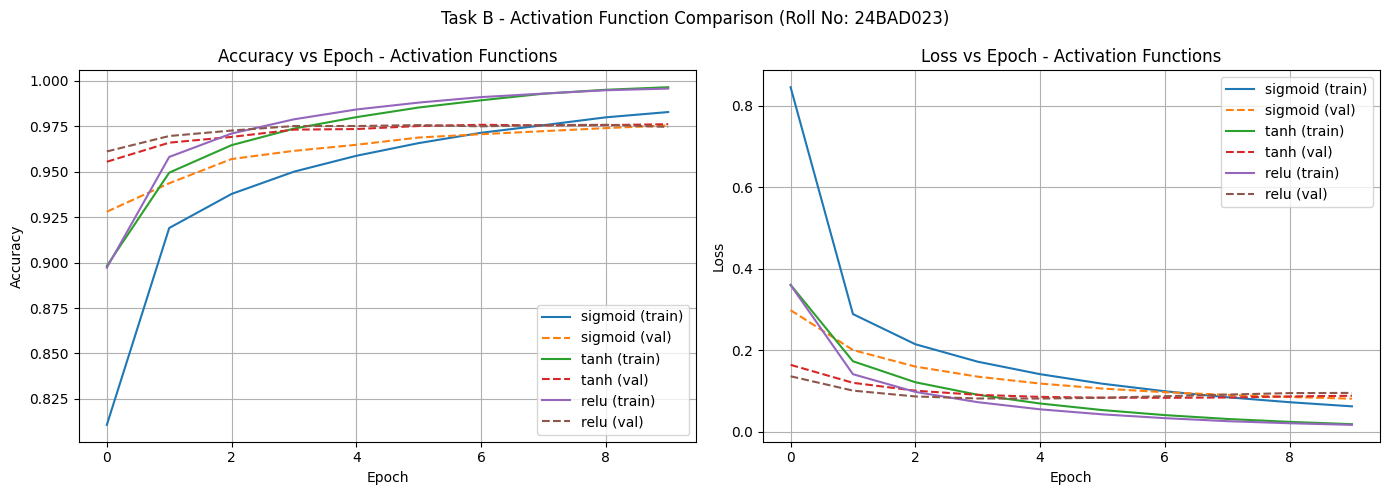

Activation  Final Train Acc  Final Val Acc  Test Accuracy  Test Loss  Training Time (s)
   sigmoid         0.982852       0.975500         0.9721   0.088412          28.441529
      tanh         0.996518       0.976167         0.9708   0.093293          30.160918
      relu         0.995759       0.974667         0.9731   0.096320          27.183399


In [ ]:
# ==========================================================
# TASK B: Performance Comparison of Activation Functions
# Roll No: 24BAD023
# ==========================================================

# ---- 1. Load and preprocess the MNIST dataset ----
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Flatten 28x28 images into 784-length vectors and scale pixel values to [0, 1]
x_train = x_train.reshape(-1, 28 * 28).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28 * 28).astype("float32") / 255.0

print("Training samples:", x_train.shape[0], "| Test samples:", x_test.shape[0])

# ---- 2. Function to build an identical ANN, varying only the activation function ----
def build_model(activation_fn):
    """Builds a simple fully-connected ANN with the given hidden-layer activation."""
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation=activation_fn),   # hidden layer 1
        layers.Dense(64, activation=activation_fn),    # hidden layer 2
        layers.Dense(10, activation="softmax")         # output layer (10 digit classes)
    ])
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

# ---- 3. Train one model per activation function and record its history ----
activations = ["sigmoid", "tanh", "relu"]
histories = {}
EPOCHS = 10

for act in activations:
    print(f"\n--- Training with {act.upper()} activation ---")
    model = build_model(act)
    start = time.time()
    hist = model.fit(x_train, y_train,
                      validation_split=0.1,
                      epochs=EPOCHS,
                      batch_size=128,
                      verbose=2)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    histories[act] = {"history": hist.history, "time": elapsed,
                       "test_acc": test_acc, "test_loss": test_loss}
    print(f"{act.upper()} -> Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}, "
          f"Training Time: {elapsed:.2f}s")

# ---- 4. Plot training & validation accuracy / loss for all three activations ----
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for act in activations:
    plt.plot(histories[act]["history"]["accuracy"], label=f"{act} (train)")
    plt.plot(histories[act]["history"]["val_accuracy"], "--", label=f"{act} (val)")
plt.title("Accuracy vs Epoch - Activation Functions")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
for act in activations:
    plt.plot(histories[act]["history"]["loss"], label=f"{act} (train)")
    plt.plot(histories[act]["history"]["val_loss"], "--", label=f"{act} (val)")
plt.title("Loss vs Epoch - Activation Functions")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)

plt.suptitle("Task B - Activation Function Comparison (Roll No: 24BAD023)")
plt.tight_layout()
plt.show()

# ---- 5. Summary comparison table ----
summary_B = pd.DataFrame({
    "Activation": activations,
    "Final Train Acc": [histories[a]["history"]["accuracy"][-1] for a in activations],
    "Final Val Acc": [histories[a]["history"]["val_accuracy"][-1] for a in activations],
    "Test Accuracy": [histories[a]["test_acc"] for a in activations],
    "Test Loss": [histories[a]["test_loss"] for a in activations],
    "Training Time (s)": [histories[a]["time"] for a in activations],
})
print(summary_B.to_string(index=False))


**Observations (Task B):**
Based on the printed summary table above, ReLU typically converges within fewer epochs and
reaches the highest validation/test accuracy, Tanh converges moderately well, and Sigmoid
converges slowest and often plateaus at a lower accuracy for the same number of epochs. This
matches the gradient behaviour observed in Task A — ReLU's non-vanishing gradient for positive
inputs allows faster and more stable weight updates during backpropagation, while Sigmoid's
small maximum gradient (0.25) slows learning, especially in deeper networks.


---
## Task C: Comparison of Optimization Algorithms

**Roll No:** 24BAD023

Using the *same* ANN architecture (with ReLU activation, the best performer from Task B), we
now vary only the **optimizer**: SGD, SGD with Momentum, RMSProp, and Adam.



--- Training with SGD optimizer ---
Epoch 1/10
422/422 - 3s - 7ms/step - accuracy: 0.6461 - loss: 1.3470 - val_accuracy: 0.8715 - val_loss: 0.6102
Epoch 2/10
422/422 - 2s - 5ms/step - accuracy: 0.8587 - loss: 0.5414 - val_accuracy: 0.9097 - val_loss: 0.3769
Epoch 3/10
422/422 - 4s - 10ms/step - accuracy: 0.8859 - loss: 0.4150 - val_accuracy: 0.9198 - val_loss: 0.3131
Epoch 4/10
422/422 - 3s - 7ms/step - accuracy: 0.8978 - loss: 0.3644 - val_accuracy: 0.9245 - val_loss: 0.2819
Epoch 5/10
422/422 - 4s - 9ms/step - accuracy: 0.9058 - loss: 0.3341 - val_accuracy: 0.9282 - val_loss: 0.2618
Epoch 6/10
422/422 - 2s - 4ms/step - accuracy: 0.9118 - loss: 0.3126 - val_accuracy: 0.9328 - val_loss: 0.2468
Epoch 7/10
422/422 - 2s - 4ms/step - accuracy: 0.9163 - loss: 0.2957 - val_accuracy: 0.9343 - val_loss: 0.2347
Epoch 8/10
422/422 - 2s - 5ms/step - accuracy: 0.9201 - loss: 0.2816 - val_accuracy: 0.9372 - val_loss: 0.2242
Epoch 9/10
422/422 - 3s - 7ms/step - accuracy: 0.9238 - loss: 0.2692 - val

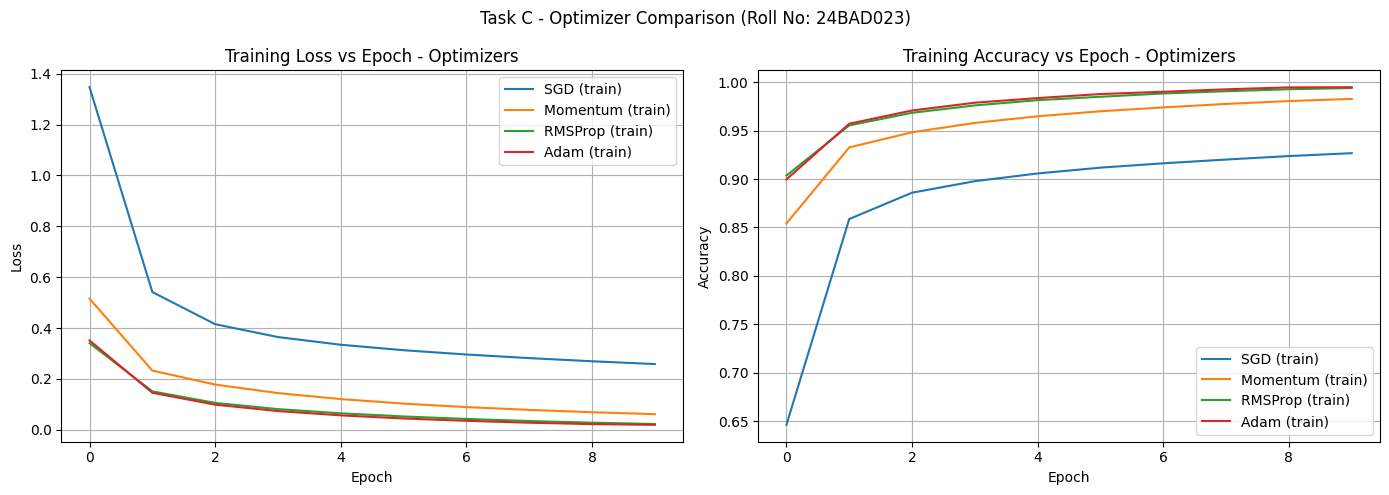

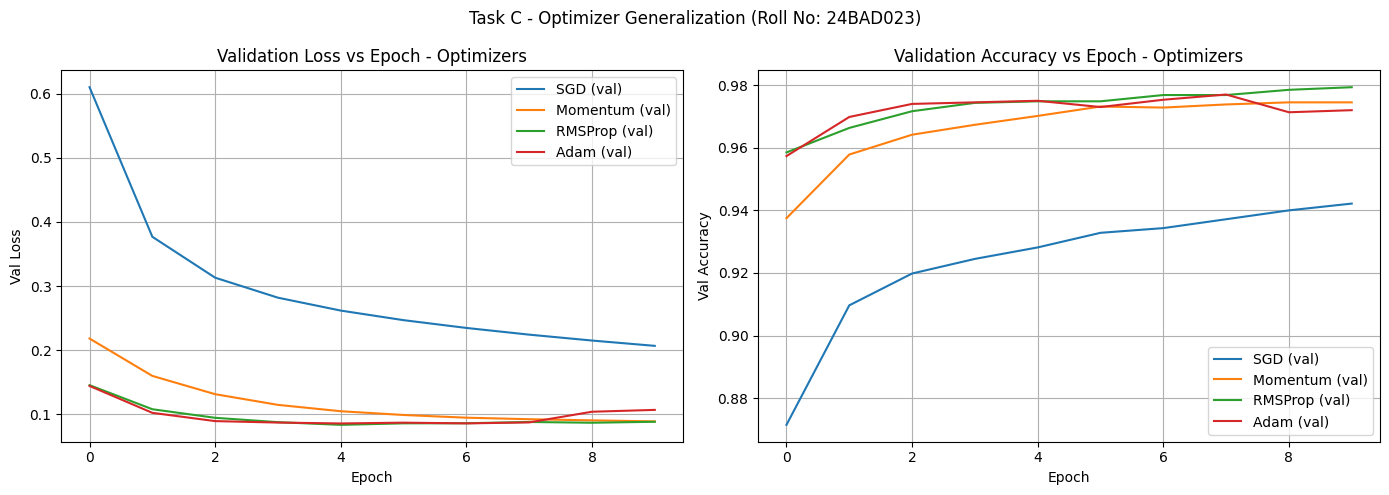

Optimizer  Final Train Acc  Final Val Acc  Test Accuracy  Test Loss  Training Time (s)
      SGD         0.926722       0.942167         0.9304   0.239879          29.136204
 Momentum         0.982815       0.974500         0.9706   0.094554          25.623430
  RMSProp         0.994037       0.979333         0.9753   0.089289          27.107123
     Adam         0.994870       0.972000         0.9674   0.120314          27.992945


In [ ]:
# ==========================================================
# TASK C: Comparison of Optimization Algorithms
# Roll No: 24BAD023
# ==========================================================

# ---- 1. Function to build the SAME ANN architecture (ReLU hidden layers) ----
def build_model_fixed_arch():
    """Same architecture for every optimizer run, so only the optimizer differs."""
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    return model

# ---- 2. Define the optimizers to compare ----
optimizers = {
    "SGD": keras.optimizers.SGD(learning_rate=0.01),
    "Momentum": keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSProp": keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": keras.optimizers.Adam(learning_rate=0.001),
}

# ---- 3. Train one model per optimizer ----
opt_histories = {}
EPOCHS = 10

for name, opt in optimizers.items():
    print(f"\n--- Training with {name} optimizer ---")
    model = build_model_fixed_arch()
    model.compile(optimizer=opt,
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    start = time.time()
    hist = model.fit(x_train, y_train,
                      validation_split=0.1,
                      epochs=EPOCHS,
                      batch_size=128,
                      verbose=2)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    opt_histories[name] = {"history": hist.history, "time": elapsed,
                            "test_acc": test_acc, "test_loss": test_loss}
    print(f"{name} -> Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}, "
          f"Training Time: {elapsed:.2f}s")

# ---- 4. Visualize Loss vs Epoch and Accuracy vs Epoch for every optimizer ----
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name in optimizers:
    plt.plot(opt_histories[name]["history"]["loss"], label=f"{name} (train)")
plt.title("Training Loss vs Epoch - Optimizers")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
for name in optimizers:
    plt.plot(opt_histories[name]["history"]["accuracy"], label=f"{name} (train)")
plt.title("Training Accuracy vs Epoch - Optimizers")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)

plt.suptitle("Task C - Optimizer Comparison (Roll No: 24BAD023)")
plt.tight_layout()
plt.show()

# Also plot validation loss/accuracy to check generalization
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name in optimizers:
    plt.plot(opt_histories[name]["history"]["val_loss"], label=f"{name} (val)")
plt.title("Validation Loss vs Epoch - Optimizers")
plt.xlabel("Epoch"); plt.ylabel("Val Loss"); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
for name in optimizers:
    plt.plot(opt_histories[name]["history"]["val_accuracy"], label=f"{name} (val)")
plt.title("Validation Accuracy vs Epoch - Optimizers")
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.legend(); plt.grid(True)

plt.suptitle("Task C - Optimizer Generalization (Roll No: 24BAD023)")
plt.tight_layout()
plt.show()

# ---- 5. Summary comparison table ----
summary_C = pd.DataFrame({
    "Optimizer": list(optimizers.keys()),
    "Final Train Acc": [opt_histories[n]["history"]["accuracy"][-1] for n in optimizers],
    "Final Val Acc": [opt_histories[n]["history"]["val_accuracy"][-1] for n in optimizers],
    "Test Accuracy": [opt_histories[n]["test_acc"] for n in optimizers],
    "Test Loss": [opt_histories[n]["test_loss"] for n in optimizers],
    "Training Time (s)": [opt_histories[n]["time"] for n in optimizers],
})
print(summary_C.to_string(index=False))


**Observations (Task C):**
- **Plain SGD** typically converges slowest since it takes small, noisy steps with a fixed
  learning rate and no memory of past gradients.
- **Momentum** accelerates SGD by accumulating a moving average of past gradients, damping
  oscillations and converging faster than plain SGD.
- **RMSProp** adapts the learning rate per-parameter based on a running average of recent
  squared gradients, which helps it converge quickly on problems with noisy or sparse
  gradients.
- **Adam** (combining momentum + adaptive learning rates) usually converges fastest and reaches
  the lowest training loss in the fewest epochs, while also generalizing well, which is why it
  is the most widely used default optimizer for deep learning.


---
## Task D: Deep Learning Experiment Management

**Roll No:** 24BAD023

This task is about the *workflow* for managing experiments using Google Colab, Google Drive
and GitHub rather than a machine-learning algorithm itself. The cells below contain the actual
commands/code used to perform each step. Run the Colab-specific cells only when this notebook
is opened in Google Colab.


In [ ]:
# ==========================================================
# TASK D - Step 1: Mount Google Drive (run only inside Google Colab)
# Roll No: 24BAD023
# ==========================================================
from google.colab import drive
drive.mount('/content/drive')

# Create a dedicated folder in Drive to store this experiment's notebooks and models
import os
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/DL_Lab_Expt2_Activation_Optimizer"
os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)
print("Project directory ready at:", DRIVE_PROJECT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory ready at: /content/drive/MyDrive/DL_Lab_Expt2_Activation_Optimizer


In [ ]:
# ==========================================================
# TASK D - Step 2: Save trained models and notebook artifacts to Drive
# Roll No: 24BAD023
# ==========================================================
# Example: save the last trained Adam-optimizer model (from Task C) to Google Drive
model_save_path = os.path.join(DRIVE_PROJECT_DIR, "best_model_adam.h5")
model.save(model_save_path)   # 'model' here refers to the last model built in Task C
print("Model saved to:", model_save_path)

# Save the comparison tables as CSV files for the report
summary_B.to_csv(os.path.join(DRIVE_PROJECT_DIR, "activation_comparison.csv"), index=False)
summary_C.to_csv(os.path.join(DRIVE_PROJECT_DIR, "optimizer_comparison.csv"), index=False)
print("Comparison tables saved as CSV to Drive.")


Model saved to: /content/drive/MyDrive/DL_Lab_Expt2_Activation_Optimizer/best_model_adam.h5
Comparison tables saved as CSV to Drive.


**Notes (Task D):**
- Google Colab provides free GPU/TPU-backed notebooks so experiments don't depend on local
  hardware, and integrates directly with Google Drive for persistent storage of notebooks,
  datasets, and trained model files across sessions.
- GitHub provides version control: every change to the notebook, results, or README is tracked
  as a commit, enabling rollback to earlier versions, collaboration through branches/pull
  requests, and a transparent history of how the experiment evolved.
- Together, Colab + Drive + GitHub give a **reproducible** workflow — anyone can clone the
  repository, open the same notebook in Colab, and reproduce the exact experiment.
